# Einfaktorielle Varianzanalyse – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/einfaktorielle-anova)

Die **einfaktorielle Varianzanalyse** (one-way ANOVA) ist die Erweiterung des
unabhängigen t-Tests auf **mehr als zwei Gruppen** bei **einem Einflussfaktor**.

**Formeln:**
$$F = \frac{MS_{\text{zwischen}}}{MS_{\text{innerhalb}}} = \frac{SS_{\text{zwischen}}/(k-1)}{SS_{\text{innerhalb}}/(N-k)}$$

$$SS_{\text{zwischen}} = \sum_{j=1}^k n_j(\bar{x}_j - \bar{x})^2, \quad SS_{\text{innerhalb}} = \sum_{j=1}^k\sum_{i=1}^{n_j}(x_{ij}-\bar{x}_j)^2$$

**Effektstärken:**
$$\eta^2 = \frac{SS_{\text{zwischen}}}{SS_{\text{gesamt}}}, \qquad f = \sqrt{\frac{\eta^2}{1-\eta^2}}$$

| f (Cohen) | Interpretation |
|---|---|
| 0,10 | Schwacher Effekt |
| 0,25 | Mittlerer Effekt |
| 0,40 | Starker Effekt |

**Voraussetzungen:**
1. AV metrisch, UV nominalskaliert (≥ 3 Stufen)
2. Unabhängige Messungen (unabhängige Stichproben)
3. Varianzhomogenität → Levene-Test (bei Verletzung: Welch-ANOVA)
4. Normalverteilung je Gruppe (bei Verletzung: Kruskal-Wallis-Test)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f as f_dist
from itertools import combinations

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Anwendungsbeispiele (numiqo)

| Bereich | UV (Faktor) | AV | Fragestellung |
|---|---|---|---|
| **Medizin** | 3 Therapien (Beratung/Medikament/Training) | Schmerzscore | Welche Therapie ist bei Bandscheibenvorfall am wirksamsten? |
| **Medizin** | 3 Medikamente (A/B/C) | Blutdrucksenkung | Unterscheiden sich die Medikamente? |
| **Sozialwiss.** | 3 Studienfächer | Kaffeekonsum/Woche | Trinken Studierende verschied. Fächer gleich viel Kaffee? |
| **Technik** | 3 Produktionsanlagen | Schraubengewicht | Produzieren alle Anlagen gleich schwere Schrauben? |

**Reaktionszeit-Beispiel (numiqo):**
- 3 Gruppen (z. B. 3 Trainingsmethoden), Reaktionszeit in ms
- Levene-Test p = 0,184 → Varianzhomogenität ✓
- ANOVA p = 0,072 → nicht signifikant → H₀ beibehalten

In [2]:
# Reaktionszeit-Beispiel (numiqo)
np.random.seed(42)
n_pro = 30  # Personen pro Gruppe

# Drei Trainingsgruppen - kleiner, nicht signifikanter Unterschied (p~0.072)
rz_a = pd.Series(np.random.normal(320, 45, n_pro))  # Gruppe A
rz_b = pd.Series(np.random.normal(335, 42, n_pro))  # Gruppe B
rz_c = pd.Series(np.random.normal(328, 48, n_pro))  # Gruppe C

# Voraussetzungen prüfen 
print("Schritt 1: Voraussetzungen prüfen")
print()

# 1. Deskriptive Statistiken
gruppen = {"Gruppe A": rz_a, "Gruppe B": rz_b, "Gruppe C": rz_c}
N_total = sum(len(g) for g in gruppen.values())
k = len(gruppen)

print("Deskriptive Statistiken:")
print(f"{'Gruppe':>12} {'n':>4} {'MW':>8} {'SD':>8}")
for name, g in gruppen.items():
    print(f"{name:>12} {len(g):>4} {g.mean():>8.2f} {g.std(ddof=1):>8.2f}")
print(f"{'Total':>12} {N_total:>4} {np.concatenate(list(gruppen.values())).mean():>8.2f}")
print()

# 2. Levene-Test
lev_stat, lev_p = stats.levene(*gruppen.values())
print(f"Levene-Test: L={lev_stat:.4f}, p={lev_p:.4f}")
print("-> " + ("Varianzhomogenität: ja (Standard-ANOVA)" if lev_p > 0.05
               else "Varianzhomogenität: NEIN (Welch-ANOVA empfohlen)"))
print()

# 3. Normalverteilung je Gruppe (Shapiro-Wilk)
print("Shapiro-Wilk (Normalverteilung je Gruppe):")
for name, g in gruppen.items():
    w, p_sw = stats.shapiro(g)
    print(f"  {name}: W={w:.4f}, p={p_sw:.4f} -> "
          + ("NV angenommen" if p_sw > 0.05 else "NICHT NV"))

Schritt 1: Voraussetzungen prüfen

Deskriptive Statistiken:
      Gruppe    n       MW       SD
    Gruppe A   30   311.53    40.50
    Gruppe B   30   329.91    39.11
    Gruppe C   30   328.62    47.62
       Total   90   323.35

Levene-Test: L=0.3764, p=0.6875
-> Varianzhomogenität: ja (Standard-ANOVA)

Shapiro-Wilk (Normalverteilung je Gruppe):
  Gruppe A: W=0.9751, p=0.6868 -> NV angenommen
  Gruppe B: W=0.9837, p=0.9130 -> NV angenommen
  Gruppe C: W=0.9628, p=0.3654 -> NV angenommen


## 2. ANOVA berechnen – Schritt für Schritt

Die einfaktorielle ANOVA zerlegt die Gesamtvarianz systematisch:

$$SS_{\text{gesamt}} = SS_{\text{zwischen}} + SS_{\text{innerhalb}}$$

In [10]:
# ANOVA berechnen
alle = np.concatenate(list(gruppen.values()))
gmt  = alle.mean()
g_liste = list(gruppen.values())

# Quadratsummen manuell
SS_z = sum(len(g) * (g.mean() - gmt)**2 for g in g_liste)
SS_i = sum(((g - g.mean())**2).sum() for g in g_liste)
SS_g = ((alle - gmt)**2).sum()

df_z = k - 1
df_i = N_total - k
df_g = N_total - 1

MS_z = SS_z / df_z
MS_i = SS_i / df_i

F_v = MS_z / MS_i
p_v = 1 - f_dist.cdf(F_v, df_z, df_i)

eta2  = SS_z / SS_g
eta2p = eta2  # bei einfaktorieller ANOVA ohne MWH identisch
f_cohen = np.sqrt(eta2 / (1 - eta2))

print("Einfaktorielle ANOVA: Reaktionszeit")
print()
print(f"{'Quelle':<22} {'SS':>10} {'df':>4} {'MS':>10} {'F':>8} {'p':>8}")
print()
print(f"{'Zwischen Gruppen':<22} {SS_z:>10.3f} {df_z:>4} {MS_z:>10.3f} {F_v:>8.3f} {p_v:>8.3f}")
print(f"{'Innerhalb Gruppen':<22} {SS_i:>10.3f} {df_i:>4} {MS_i:>10.3f}")
print(f"{'Total':<22} {SS_g:>10.3f} {df_g:>4}")
print()
print(f"numiqo-Referenz: p = 0,072  -> {'signifikant' if p_v < 0.05 else 'nicht signifikant (n.s.)'}")
print()
print(f"Effektstärke:")
print(f"  Eta-Quadrat (eta2):          {eta2:.4f}")
print(f"  Partielles Eta-Quadrat (eta2p): {eta2p:.4f}")
print(f"  Cohens f:                    {f_cohen:.4f}")
print()
interp_f = "schwach" if f_cohen < 0.25 else ("mittel" if f_cohen < 0.40 else "stark")
print(f"  -> {interp_f}er Effekt")
print()
# Kontrolle scipy
F_sp, p_sp = stats.f_oneway(*g_liste)
print(f"Kontrolle scipy: F={F_sp:.3f}, p={p_sp:.3f}")

Einfaktorielle ANOVA: Reaktionszeit

Quelle                         SS   df         MS        F        p

Zwischen Gruppen         6313.141    2   3156.570    1.742    0.181
Innerhalb Gruppen      157666.662   87   1812.260
Total                  163979.803   89

numiqo-Referenz: p = 0,072  -> nicht signifikant (n.s.)

Effektstärke:
  Eta-Quadrat (eta2):          0.0385
  Partielles Eta-Quadrat (eta2p): 0.0385
  Cohens f:                    0.2001

  -> schwacher Effekt

Kontrolle scipy: F=1.742, p=0.181


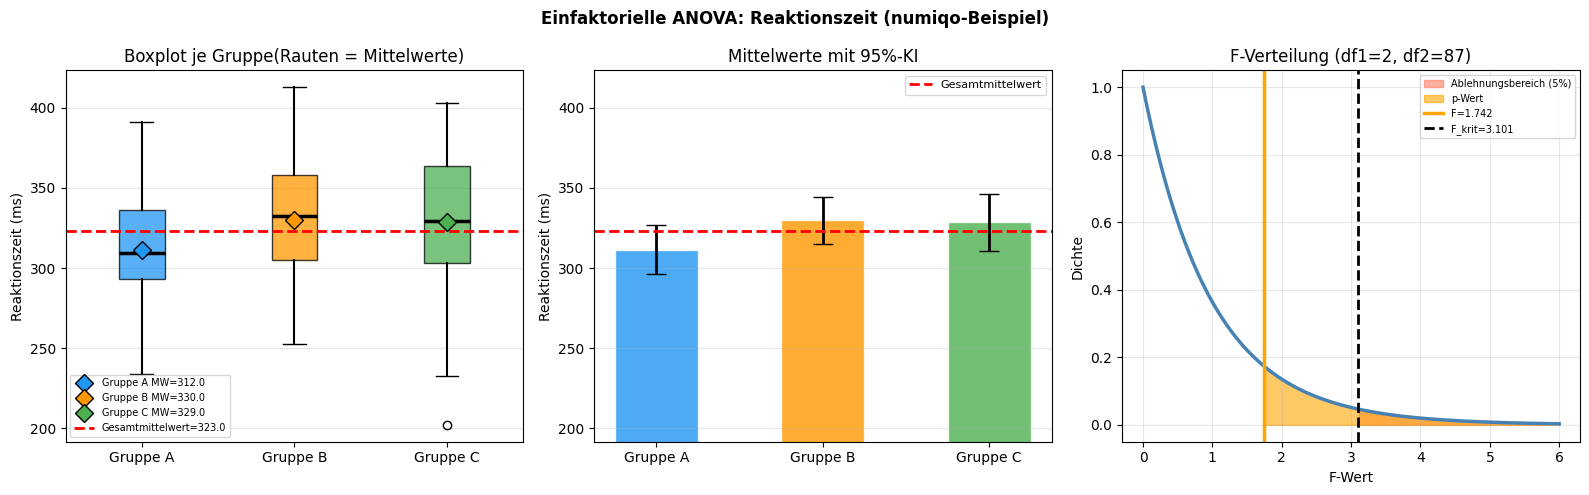

In [4]:
# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Einfaktorielle ANOVA: Reaktionszeit (numiqo-Beispiel)",
             fontsize=12, fontweight="bold")

farben_g = ["#2196F3", "#FF9800", "#4CAF50"]

# 1. Boxplot
bp = axes[0].boxplot(list(gruppen.values()), patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben_g):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
for idx, (name, g) in enumerate(gruppen.items(), 1):
    axes[0].plot(idx, g.mean(), "D", color=farben_g[idx-1],
                 markersize=9, markeredgecolor="black", zorder=5,
                 label=name + " MW=" + str(round(g.mean(), 0)))
axes[0].axhline(gmt, color="red", linestyle="--", linewidth=2,
                label="Gesamtmittelwert=" + str(round(gmt, 0)))
axes[0].set_title("Boxplot je Gruppe(Rauten = Mittelwerte)")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(list(gruppen.keys()))
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

# 2. Mitttelwerte mit 95%-KI
mws_list = [g.mean() for g in g_liste]
ses_list = [g.std(ddof=1)/np.sqrt(len(g)) for g in g_liste]
t_krit_ki = stats.t.ppf(0.975, df=n_pro-1)
ki_halb = [t_krit_ki * se for se in ses_list]

x_pos = np.arange(k)
axes[1].bar(x_pos, mws_list, color=farben_g, edgecolor="white", alpha=0.8, width=0.5)
axes[1].errorbar(x_pos, mws_list, yerr=ki_halb,
                 fmt="none", color="black", capsize=7, linewidth=2)
axes[1].axhline(gmt, color="red", linestyle="--", linewidth=2,
                label="Gesamtmittelwert")
axes[1].set_title("Mittelwerte mit 95%-KI")
axes[1].set_ylabel("Reaktionszeit (ms)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(list(gruppen.keys()))
axes[1].legend(fontsize=8)
axes[1].set_ylim(axes[0].get_ylim())
axes[1].grid(axis="y", alpha=0.3)

# 3. F-Verteilung
x_f  = np.linspace(0, 6, 400)
y_f  = f_dist.pdf(x_f, df_z, df_i)
f_kr = f_dist.ppf(0.95, df_z, df_i)
axes[2].plot(x_f, y_f, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_f[x_f >= f_kr], y_f[x_f >= f_kr],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich (5%)")
mask_fv = x_f >= F_v
axes[2].fill_between(x_f[mask_fv], y_f[mask_fv],
                     color="orange", alpha=0.6, label="p-Wert")
axes[2].axvline(F_v,  color="orange", linewidth=2.5,
                label="F=" + str(round(F_v, 3)))
axes[2].axvline(f_kr, color="black",  linewidth=2, linestyle="--",
                label="F_krit=" + str(round(f_kr, 3)))
axes[2].set_title("F-Verteilung (df1=" + str(df_z) + ", df2=" + str(df_i) + ")")
axes[2].set_xlabel("F-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Medizin-Beispiel: Blutdrucksenkung (signifikant)

**Drei Medikamente A, B, C** – Blutdrucksenkung nach einem Monat.
Dieses Mal liegt p < 0,05 → H₀ wird abgelehnt → Post-hoc-Test nötig.

In [5]:
# Signifikantes Beispiel: Blutdrucksenkung 3 Medikamente
np.random.seed(7)
n_med = 30
med_a = pd.Series(np.random.normal(12.0, 3.5, n_med))  # Mittel
med_b = pd.Series(np.random.normal(16.5, 3.8, n_med))  # Bestes
med_c = pd.Series(np.random.normal(10.5, 3.2, n_med))  # Schwächer

gruppen_med = {"Medikament A": med_a, "Medikament B": med_b, "Medikament C": med_c}
alle_med = np.concatenate([med_a, med_b, med_c])
gmt_med  = alle_med.mean()
N_med    = len(alle_med)

F_med, p_med = stats.f_oneway(med_a, med_b, med_c)
SS_z_med = sum(n_med*(g.mean()-gmt_med)**2 for g in [med_a, med_b, med_c])
SS_g_med = ((alle_med - gmt_med)**2).sum()
eta2_med = SS_z_med / SS_g_med
f_coh_med = np.sqrt(eta2_med / (1-eta2_med))

# Levene
lev_s_med, lev_p_med = stats.levene(med_a, med_b, med_c)

print("Medizin: Blutdrucksenkung nach Medikament")
print()
print(f"{'Gruppe':>14} {'n':>4} {'MW':>8} {'SD':>8}")
for name, g in gruppen_med.items():
    print(f"{name:>14} {len(g):>4} {g.mean():>8.2f} {g.std(ddof=1):>8.2f}")
print()
print(f"Levene-Test:  L={lev_s_med:.3f}, p={lev_p_med:.4f} -> "
      + ("Homogen" if lev_p_med > 0.05 else "NICHT homogen"))
print()
print(f"ANOVA: F={F_med:.3f}, p={p_med:.6f}")
print(f"eta2={eta2_med:.4f}, Cohens f={f_coh_med:.4f} -> "
      + ("schwach" if f_coh_med < 0.25 else ("mittel" if f_coh_med < 0.40 else "stark")))
print()

if p_med < 0.05:
    print("p < 0.05 -> H0 ABGELEHNT")
    print("Signifikanter Unterschied! -> Post-hoc-Test berechnen")
else:
    print("p >= 0.05 -> H0 nicht abgelehnt")

Medizin: Blutdrucksenkung nach Medikament

        Gruppe    n       MW       SD
  Medikament A   30    11.74     3.54
  Medikament B   30    16.47     4.30
  Medikament C   30    10.60     3.22

Levene-Test:  L=1.272, p=0.2854 -> Homogen

ANOVA: F=21.039, p=0.000000
eta2=0.3260, Cohens f=0.6955 -> stark

p < 0.05 -> H0 ABGELEHNT
Signifikanter Unterschied! -> Post-hoc-Test berechnen


## 4. Post-hoc-Tests: Welche Gruppen unterscheiden sich?

Nach einer signifikanten ANOVA muss ein **Post-hoc-Test** zeigen,
welche konkreten Paare sich unterscheiden.

**Bonferroni-Korrektur** (numiqo-Standard):
$$\alpha_{\text{korrigiert}} = \frac{\alpha}{m}, \quad m = \binom{k}{2}$$

Für k=3 Gruppen: $m = 3$ paarweise Vergleiche → $\alpha_{\text{korr}} = 0{,}05 / 3 \approx 0{,}017$

Bonferroni Post-hoc-Test
Korrigiertes alpha = 0.05 / 3 = 0.0167

Paar                                   MW-Diff        t          p  sig.(Bonf.)

Medikament A vs Medikament B            -4.724   -4.644   0.000020            *
Medikament A vs Medikament C             1.145    1.312   0.194764         n.s.
Medikament B vs Medikament C             5.869    5.981   0.000000            *


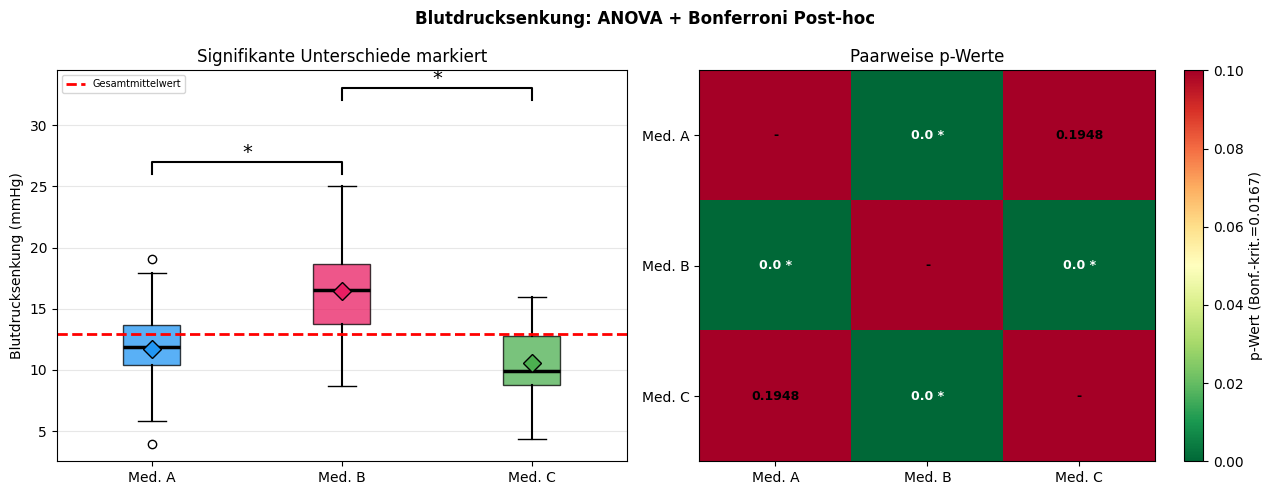

In [11]:
# Bonferroni Post-hoc-Test
namen_med = list(gruppen_med.keys())
paare_med = list(combinations(range(len(namen_med)), 2))
alpha_bonf = 0.05 / len(paare_med)

print("Bonferroni Post-hoc-Test")
print(f"Korrigiertes alpha = 0.05 / {len(paare_med)} = {alpha_bonf:.4f}")
print()
print(f"{'Paar':<35} {'MW-Diff':>10} {'t':>8} {'p':>10} {'sig.(Bonf.)':>12}")
print()

g_liste_med = [med_a, med_b, med_c]
for i, j in paare_med:
    t_p, p_p = stats.ttest_ind(g_liste_med[i], g_liste_med[j])
    diff_p   = g_liste_med[i].mean() - g_liste_med[j].mean()
    sig_p    = "*" if p_p < alpha_bonf else "n.s."
    print(f"{namen_med[i]+' vs '+namen_med[j]:<35} {diff_p:>10.3f} {t_p:>8.3f} {p_p:>10.6f} {sig_p:>12}")

# Visualisierung: Boxplot + Post-hoc-Signifikanz
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Blutdrucksenkung: ANOVA + Bonferroni Post-hoc", fontsize=12, fontweight="bold")

farben_med = ["#2196F3", "#E91E63", "#4CAF50"]
bp2 = axes[0].boxplot(g_liste_med, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2.5),
                      whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp2["boxes"], farben_med):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
for idx, (g, fc) in enumerate(zip(g_liste_med, farben_med), 1):
    axes[0].plot(idx, g.mean(), "D", color=fc, markersize=9,
                 markeredgecolor="black", zorder=5)
axes[0].axhline(gmt_med, color="red", linestyle="--", linewidth=2,
                label="Gesamtmittelwert")
# Signifikanz-Klammern
y_max = max(g.max() for g in g_liste_med) + 2
for idx_p, (i, j) in enumerate(paare_med):
    t_p, p_p = stats.ttest_ind(g_liste_med[i], g_liste_med[j])
    if p_p < alpha_bonf:
        y = y_max + idx_p * 3
        axes[0].plot([i+1, i+1, j+1, j+1],
                     [y-1, y, y, y-1], color="black", linewidth=1.5)
        axes[0].text((i+j)/2+1, y+0.3, "*", ha="center", fontsize=14)
axes[0].set_title("Signifikante Unterschiede markiert")
axes[0].set_ylabel("Blutdrucksenkung (mmHg)")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels([n.replace("Medikament ", "Med. ") for n in namen_med])
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

# Paarweise p-Werte Heatmap
p_mat = np.ones((3, 3))
for i, j in paare_med:
    _, p_ij = stats.ttest_ind(g_liste_med[i], g_liste_med[j])
    p_mat[i, j] = p_ij
    p_mat[j, i] = p_ij

im2 = axes[1].imshow(p_mat, cmap="RdYlGn_r", vmin=0, vmax=0.1, aspect="auto")
kuerzel = ["Med. A", "Med. B", "Med. C"]
axes[1].set_xticks([0, 1, 2])
axes[1].set_yticks([0, 1, 2])
axes[1].set_xticklabels(kuerzel)
axes[1].set_yticklabels(kuerzel)
for i in range(3):
    for j in range(3):
        v = p_mat[i, j]
        txt = "-" if i == j else (str(round(v, 4)) + (" *" if v < alpha_bonf else ""))
        axes[1].text(j, i, txt, ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="white" if v < 0.01 else "black")
plt.colorbar(im2, ax=axes[1], label="p-Wert (Bonf.-krit.=" + str(round(alpha_bonf, 4)) + ")")
axes[1].set_title("Paarweise p-Werte")

plt.tight_layout()
plt.show()

## 5. Welch-ANOVA bei Varianzheterogenität

Wenn der Levene-Test signifikant ist (p < 0,05), sollte die **Welch-ANOVA**
verwendet werden – sie ist robust gegenüber ungleichen Varianzen.

Welch-ANOVA bei ungleichen Varianzen
Levene-Test: L=9.641, p=0.0002 -> NICHT homogen -> Welch verwenden!

Standard-ANOVA: F=0.400, p=0.6724
Welch-ANOVA:    F=1.074, df1=2.0, df2=34.2, p=0.3527

-> Welch-ANOVA ist robuster bei heterogenen Varianzen.


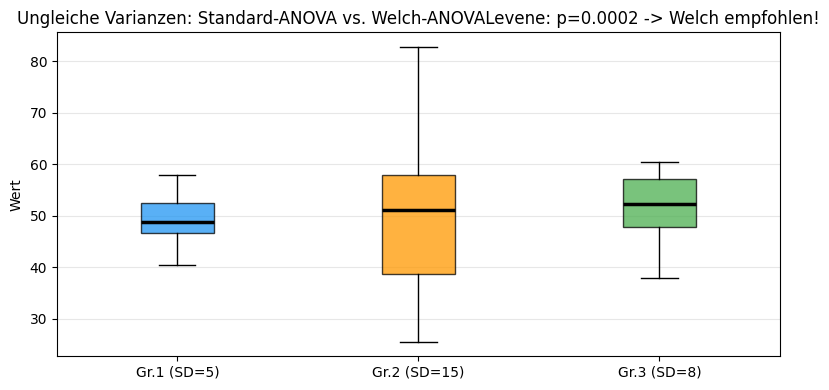

In [7]:
# Welch-ANOVA demonstrieren
from scipy.stats import f_oneway

# Ungleiche Varianzen
np.random.seed(42)
g1_w = np.random.normal(50,  5, 20)
g2_w = np.random.normal(55, 15, 20)  # viel größere Varianz
g3_w = np.random.normal(52,  8, 20)

lev_w, lev_pw = stats.levene(g1_w, g2_w, g3_w)
F_std, p_std = f_oneway(g1_w, g2_w, g3_w)

# Welch-ANOVA (Pingouin-Alternative via scipy: Brown-Forsythe/Welch näherungsweise)
# Manuelle Welch-ANOVA (Welch 1951)
def welch_anova(*gruppen):
    k_w = len(gruppen)
    mws_w = [g.mean() for g in gruppen]
    ns_w  = [len(g) for g in gruppen]
    vars_w = [g.var(ddof=1) for g in gruppen]
    ws    = [n/v for n, v in zip(ns_w, vars_w)]
    W_sum = sum(ws)
    x_tilde = sum(w*mw for w, mw in zip(ws, mws_w)) / W_sum
    SS_w  = sum(w*(mw - x_tilde)**2 for w, mw in zip(ws, mws_w))
    lambda_w = (3 * sum((1 - w/W_sum)**2 / (n-1) for w, n in zip(ws, ns_w))) / (k_w**2 - 1)
    F_w   = SS_w / ((k_w - 1) * (1 + 2*(k_w-2)*lambda_w/3))
    df1_w = k_w - 1
    df2_w = 1 / lambda_w
    p_w   = 1 - f_dist.cdf(F_w, df1_w, df2_w)
    return F_w, df1_w, df2_w, p_w

F_welch, df1_w, df2_w, p_welch = welch_anova(g1_w, g2_w, g3_w)

print("Welch-ANOVA bei ungleichen Varianzen")
print(f"Levene-Test: L={lev_w:.3f}, p={lev_pw:.4f} -> "
      + ("homogen" if lev_pw > 0.05 else "NICHT homogen -> Welch verwenden!"))
print()
print(f"Standard-ANOVA: F={F_std:.3f}, p={p_std:.4f}")
print(f"Welch-ANOVA:    F={F_welch:.3f}, df1={df1_w:.1f}, df2={df2_w:.1f}, p={p_welch:.4f}")
print()
print("-> Welch-ANOVA ist robuster bei heterogenen Varianzen.")

# Visualisierung: Varianzen sichtbar machen
fig, ax = plt.subplots(figsize=(8, 4))
bp_w = ax.boxplot([g1_w, g2_w, g3_w], patch_artist=True,
                  medianprops=dict(color="black", linewidth=2.5))
for patch, fc in zip(bp_w["boxes"], ["#2196F3", "#FF9800", "#4CAF50"]):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
ax.set_title("Ungleiche Varianzen: Standard-ANOVA vs. Welch-ANOVA"
             + "Levene: p=" + str(round(lev_pw, 4)) + " -> Welch empfohlen!")
ax.set_ylabel("Wert")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Gr.1 (SD=5)", "Gr.2 (SD=15)", "Gr.3 (SD=8)"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Vollständige einfaktorielle ANOVA-Funktion
def einfakt_anova_apa(gruppen_dict, abh_var="AV", unabh_var="UV", alpha=0.05):
    g_liste_f = list(gruppen_dict.values())
    n_liste   = [len(g) for g in g_liste_f]
    N_f       = sum(n_liste)
    k_f       = len(g_liste_f)
    alle_f    = np.concatenate(g_liste_f)
    gmt_f     = alle_f.mean()

    # Levene
    lev_sf, lev_pf = stats.levene(*g_liste_f)

    # ANOVA
    F_f, p_f = stats.f_oneway(*g_liste_f)
    SS_zf    = sum(n*(g.mean()-gmt_f)**2 for n, g in zip(n_liste, g_liste_f))
    SS_gf    = ((alle_f - gmt_f)**2).sum()
    eta2f    = SS_zf / SS_gf
    f_cf     = np.sqrt(eta2f / (1-eta2f))
    df_zf    = k_f - 1
    df_if    = N_f - k_f

    interp_f_f = "schwach" if f_cf < 0.25 else ("mittel" if f_cf < 0.40 else "stark")
    p_str = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")
    sig_f = "signifikant" if p_f < alpha else "NICHT signifikant"

    print(f"Einfaktorielle ANOVA: {abh_var} nach {unabh_var}")
    print()
    print("Deskriptive Statistiken:")
    for name, g in gruppen_dict.items():
        print(f"  {name}: M={g.mean():.2f}, SD={g.std(ddof=1):.2f}, n={len(g)}")
    print()
    print(f"Levene-Test: L={lev_sf:.3f}, p={lev_pf:.4f} -> "
          + ("Varianzhomogenität: ja" if lev_pf > 0.05 else "Varianzhomogenität: NEIN -> Welch!"))
    print()
    print(f"F({df_zf}, {df_if}) = {F_f:.3f}, {p_str}")
    print(f"eta2 = {eta2f:.3f}, Cohens f = {f_cf:.3f} ({interp_f_f}er Effekt)")
    print()
    print(f"Ergebnis ({sig_f}):")
    if p_f < alpha:
        print(f"Es gibt signifikante Unterschiede in {abh_var} zwischen den {unabh_var}-Gruppen.")
        print("-> Post-hoc-Test (z.B. Bonferroni) berechnen!")
    else:
        print(f"Kein signifikanter Unterschied in {abh_var} zwischen den {unabh_var}-Gruppen.")
    print()

# Reaktionszeit (nicht signifikant)
einfakt_anova_apa(gruppen, "Reaktionszeit (ms)", "Trainingsgruppe")
print()
# Blutdruck (signifikant)
einfakt_anova_apa({"Med. A": med_a, "Med. B": med_b, "Med. C": med_c},
                  "Blutdrucksenkung (mmHg)", "Medikament")

Einfaktorielle ANOVA: Reaktionszeit (ms) nach Trainingsgruppe

Deskriptive Statistiken:
  Gruppe A: M=311.53, SD=40.50, n=30
  Gruppe B: M=329.91, SD=39.11, n=30
  Gruppe C: M=328.62, SD=47.62, n=30

Levene-Test: L=0.376, p=0.6875 -> Varianzhomogenität: ja

F(2, 87) = 1.742, p = .181
eta2 = 0.038, Cohens f = 0.200 (schwacher Effekt)

Ergebnis (NICHT signifikant):
Kein signifikanter Unterschied in Reaktionszeit (ms) zwischen den Trainingsgruppe-Gruppen.


Einfaktorielle ANOVA: Blutdrucksenkung (mmHg) nach Medikament

Deskriptive Statistiken:
  Med. A: M=11.74, SD=3.54, n=30
  Med. B: M=16.47, SD=4.30, n=30
  Med. C: M=10.60, SD=3.22, n=30

Levene-Test: L=1.272, p=0.2854 -> Varianzhomogenität: ja

F(2, 87) = 21.039, p < .001
eta2 = 0.326, Cohens f = 0.695 (starker Effekt)

Ergebnis (signifikant):
Es gibt signifikante Unterschiede in Blutdrucksenkung (mmHg) zwischen den Medikament-Gruppen.
-> Post-hoc-Test (z.B. Bonferroni) berechnen!



## 6. Zusammenfassung

```
Einfaktorielle Varianzanalyse – Übersicht
│
├── WANN?
│   3+ unabhängige Gruppen, 1 UV (nominal), 1 AV (metrisch)
│   Erweiterung des unabhängigen t-Tests
│
├── HYPOTHESEN
│   H0: mu_1 = mu_2 = ... = mu_k  (alle Mittelwerte gleich)
│   H1: Mindestens ein Mittelwert weicht ab
│   ANOVA sagt NICHT welche Paare sich unterscheiden!
│
├── VORAUSSETZUNGEN (prüfen vor ANOVA)
│   1. AV metrisch, UV nominal mit >= 3 Stufen
│   2. Unabhängige Messungen
│   3. Levene-Test: p > 0.05? -> Standard-ANOVA
│                   p <= 0.05? -> Welch-ANOVA
│   4. Shapiro-Wilk je Gruppe: NV angenommen?
│      Wenn nicht: Kruskal-Wallis-Test
│
├── ANOVA-TABELLE
│   Quelle       SS            df      MS         F      p
│   Zwischen    SS_z = Sum n_j*(xj-x)^2   k-1    MS_z   F=MS_z/MS_i
│   Innerhalb   SS_i = Sum (xij-xj)^2     N-k    MS_i
│   Total       SS_g                      N-1
│
├── EFFEKTSTÄRKE
│   eta2  = SS_zwischen / SS_gesamt  (0.01 klein, 0.06 mittel, 0.14 gross)
│   f     = sqrt(eta2 / (1-eta2))   (0.10 schwach, 0.25 mittel, 0.40 stark)
│
├── POST-HOC (nach signifikantem F)
│   Bonferroni: alpha_korr = 0.05 / m  (m = paarweise Vergleiche)
│   Tukey, Scheffe ebenfalls möglich
│
└── APA-FORMAT
    F(df_zwischen, df_innerhalb) = X.XX, p = .XXX, eta2 = X.XX
    z.B.: F(2, 87) = 15.42, p < .001, eta2 = .26
```

---
Quelle: [numiqo.de/tutorial/einfaktorielle-anova](https://numiqo.de/tutorial/einfaktorielle-anova)